<a href="https://colab.research.google.com/github/pranil019/Customer-Churn-Prediction/blob/main/CustomerChurnPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline

df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.sample(10)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2213,5197-YPYBZ,Female,0,Yes,Yes,12,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.25,274.7,No
3255,4827-LTQRJ,Female,1,Yes,Yes,66,Yes,Yes,Fiber optic,Yes,...,No,Yes,Yes,Yes,One year,Yes,Credit card (automatic),110.60,7210.85,No
5009,0052-DCKON,Male,0,Yes,No,66,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,No,Bank transfer (automatic),115.80,7942.15,No
4641,9895-VFOXH,Female,0,No,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,24.40,24.4,No
6591,5832-XKAES,Male,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.80,134.7,Yes
180,6317-YPKDH,Female,0,No,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),29.95,29.95,Yes
2238,1393-IMKZG,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,95.85,95.85,No
1841,8958-JPTRR,Female,0,Yes,No,56,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Electronic check,24.30,1261.7,No
3802,7698-YFGEZ,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.00,20,No
1144,0841-NULXI,Male,0,No,No,1,No,No phone service,DSL,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,35.55,35.55,Yes


In [53]:
df.drop('customerID',axis='columns',inplace=True)
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [54]:
df.TotalCharges.values

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [55]:
df.MonthlyCharges.values

array([ 29.85,  56.95,  53.85, ...,  29.6 ,  74.4 , 105.65])

In [56]:
pd.to_numeric(df.TotalCharges,errors='coerce').isnull()

,TotalCharges
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [57]:
df[pd.to_numeric(df.TotalCharges,errors='coerce').isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [58]:
df.iloc[488]['TotalCharges']

' '

In [59]:
df1=df[df.TotalCharges!=' ']
df1.shape

(7032, 20)

In [60]:
df1.TotalCharges=pd.to_numeric(df1.TotalCharges)

/tmp/ipykernel_302/695980592.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.TotalCharges=pd.to_numeric(df1.TotalCharges)


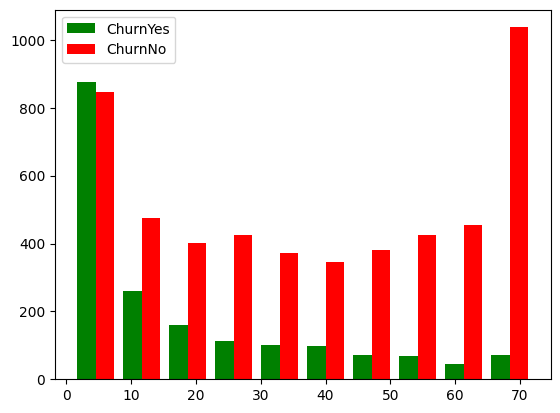

In [61]:
tenure_churn_no=df1[df1.Churn=='No'].tenure
tenure_churn_yes=df1[df1.Churn=='Yes'].tenure

plt.hist([tenure_churn_yes,tenure_churn_no],color=['green','red'],label=['ChurnYes','ChurnNo'])
plt.legend()

In [62]:
def print_unique_col_values(df):
  for column in df:
      if df[column].dtypes=='object':
          print(f'(column) : {df[column].unique()}')

In [63]:
print_unique_col_values(df1)

(column) : ['Female' 'Male']
(column) : ['Yes' 'No']
(column) : ['No' 'Yes']
(column) : ['No' 'Yes']
(column) : ['No phone service' 'No' 'Yes']
(column) : ['DSL' 'Fiber optic' 'No']
(column) : ['No' 'Yes' 'No internet service']
(column) : ['Yes' 'No' 'No internet service']
(column) : ['No' 'Yes' 'No internet service']
(column) : ['No' 'Yes' 'No internet service']
(column) : ['No' 'Yes' 'No internet service']
(column) : ['No' 'Yes' 'No internet service']
(column) : ['Month-to-month' 'One year' 'Two year']
(column) : ['Yes' 'No']
(column) : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
(column) : ['No' 'Yes']


In [64]:
df1.replace('No internet service','No',inplace=True)
df1.replace('No phone service','No',inplace=True)

/tmp/ipykernel_302/2045096646.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace('No internet service','No',inplace=True)
/tmp/ipykernel_302/2045096646.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace('No phone service','No',inplace=True)


In [65]:
print_unique_col_values(df1)

(column) : ['Female' 'Male']
(column) : ['Yes' 'No']
(column) : ['No' 'Yes']
(column) : ['No' 'Yes']
(column) : ['No' 'Yes']
(column) : ['DSL' 'Fiber optic' 'No']
(column) : ['No' 'Yes']
(column) : ['Yes' 'No']
(column) : ['No' 'Yes']
(column) : ['No' 'Yes']
(column) : ['No' 'Yes']
(column) : ['No' 'Yes']
(column) : ['Month-to-month' 'One year' 'Two year']
(column) : ['Yes' 'No']
(column) : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
(column) : ['No' 'Yes']


In [66]:
yes_no_columns=['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in yes_no_columns:
  df1.loc[:, col] = df1[col].replace({'Yes':1,'No':0})

/tmp/ipykernel_302/3566082423.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1.loc[:, col] = df1[col].replace({'Yes':1,'No':0})


In [67]:
for col in df1:
  print(f'{col}:{df1[col].unique()}')

gender:['Female' 'Male']
SeniorCitizen:[0 1]
Partner:[1 0]
Dependents:[0 1]
tenure:[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService:[0 1]
MultipleLines:[0 1]
InternetService:['DSL' 'Fiber optic' 'No']
OnlineSecurity:[0 1]
OnlineBackup:[1 0]
DeviceProtection:[0 1]
TechSupport:[0 1]
StreamingTV:[0 1]
StreamingMovies:[0 1]
Contract:['Month-to-month' 'One year' 'Two year']
PaperlessBilling:[1 0]
PaymentMethod:['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges:[29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges:[  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn:[0 1]


In [68]:
df1.loc[:, 'gender'] = df1['gender'].replace({'Female':1,'Male':0})

/tmp/ipykernel_302/3712387000.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1.loc[:, 'gender'] = df1['gender'].replace({'Female':1,'Male':0})


In [69]:
df1['gender'].unique()

array([1, 0], dtype=object)

In [70]:
df2=pd.get_dummies(data=df1,columns=['InternetService','Contract','PaymentMethod'])
df2.columns
df2.to_string()

'     gender  SeniorCitizen Partner Dependents  tenure PhoneService MultipleLines OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies PaperlessBilling  MonthlyCharges  TotalCharges Churn  InternetService_DSL  InternetService_Fiber optic  InternetService_No  Contract_Month-to-month  Contract_One year  Contract_Two year  PaymentMethod_Bank transfer (automatic)  PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  PaymentMethod_Mailed check\n0         1              0       1          0       1            0             0              0            1                0           0           0               0                1           29.85         29.85     0                 True                        False               False                     True              False              False                                    False                                  False                            True                       False\n1         0  

In [73]:
df2.sample

<bound method NDFrame.sample of      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0         1              0       1          0       1            0   
1         0              0       0          0      34            1   
2         0              0       0          0       2            1   
3         0              0       0          0      45            0   
4         1              0       0          0       2            1   
...     ...            ...     ...        ...     ...          ...   
7038      0              0       1          1      24            1   
7039      1              0       1          1      72            1   
7040      1              0       1          1      11            0   
7041      0              1       1          0       4            1   
7042      0              0       0          0      66            1   

     MultipleLines OnlineSecurity OnlineBackup DeviceProtection  ...  \
0                0              0            1                0  ...   
1                0              1            0                1  ...   
2                0              1            1                0  ...   
3                0              1            0                1  ...   
4                0              0            0                0  ...   
...            ...            ...          ...              ...  ...   
7038             1              1            0                1  ...   
7039             1              0            1                1  ...   
7040             0              1            0                0  ...   
7041             1              0            0                0  ...   
7042             0              1            0                1  ...   

     InternetService_DSL InternetService_Fiber optic InternetService_No  \
0                   True                       False              False   
1                   True                       False              False   
2                   True                       False              False   
3                   True                       False              False   
4                  False                        True              False   
...                  ...                         ...                ...   
7038                True                       False              False   
7039               False                        True              False   
7040                True                       False              False   
7041               False                        True              False   
7042               False                        True              False   

     Contract_Month-to-month  Contract_One year  Contract_Two year  \
0                       True              False              False   
1                      False               True              False   
2                       True              False              False   
3                      False               True              False   
4                       True              False              False   
...                      ...                ...                ...   
7038                   False               True              False   
7039                   False               True              False   
7040                    True              False              False   
7041                    True              False              False   
7042                   False              False               True   

     PaymentMethod_Bank transfer (automatic)  \
0                                      False   
1                                      False   
2                                      False   
3                                       True   
4                                      False   
...                                      ...   
7038                                   False   
7039                                   False   
7040                                   False   
7041                                   F

Training and Testing Data

In [82]:
X=df2.drop('Churn',axis='columns')
y=df2['Churn']

# Convert y to integer type before splitting
y = y.astype(int)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=5)

cols_to_scale=['tenure','MonthlyCharges','TotalCharges']
schaler=MinMaxScaler()
X_train[cols_to_scale]=scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]=scaler.transform(X_test[cols_to_scale])

# Convert boolean columns to int for Keras compatibility
for col in X_train.select_dtypes(include=['bool']).columns:
    X_train[col] = X_train[col].astype(int)
for col in X_test.select_dtypes(include=['bool']).columns:
    X_test[col] = X_test[col].astype(int)

# Final check and conversion for any remaining object columns
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype(int)
for col in X_test.select_dtypes(include=['object']).columns:
    X_test[col] = X_test[col].astype(int)

In [74]:
X_train.shape

(5625, 26)

In [75]:
X_test.shape

(1407, 26)

In [76]:
X_train[:10]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5664,1,1,0,0,0.126761,1,0,0,0,1,...,False,True,False,True,False,False,False,True,False,False
101,1,0,1,1,0.000000,1,0,0,0,0,...,False,False,True,True,False,False,False,False,True,False
2621,0,0,1,0,0.985915,1,0,0,1,1,...,True,False,False,False,False,True,False,True,False,False
392,1,1,0,0,0.014085,1,0,0,0,0,...,True,False,False,True,False,False,False,False,True,False
1327,0,0,1,0,0.816901,1,1,0,0,1,...,False,True,False,False,True,False,True,False,False,False
3607,1,0,0,0,0.169014,1,0,1,0,0,...,True,False,False,False,True,False,False,False,False,True
2773,0,0,1,0,0.323944,0,0,0,0,1,...,True,False,False,True,False,False,False,False,True,False
1936,1,0,1,0,0.704225,1,0,1,1,0,...,True,False,False,False,True,False,True,False,False,False
5387,0,0,0,0,0.042254,0,0,0,0,0,...,True,False,False,True,False,False,False,False,True,False
4331,0,0,0,0,0.985915,1,1,0,0,0,...,False,False,True,False,False,True,True,False,False,False


In [77]:
len(X_train.columns)

26

In [83]:
import tensorflow as tf
from tensorflow import keras

model=keras.Sequential([
    keras.Input(shape=(26,)), # Recommended way to define input shape
    keras.layers.Dense(26),
    keras.layers.Dense(15,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')

])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train,y_train,epochs=10)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7856 - loss: 0.4547
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7984 - loss: 0.4218
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8027 - loss: 0.4172
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8027 - loss: 0.4145
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8076 - loss: 0.4120
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8075 - loss: 0.4117
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8059 - loss: 0.4099
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8085 - loss: 0.4092
Epoch 9/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8069 - loss: 0.4082
Epoch 10/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8073 - loss: 0.4070


In [88]:
loss,accuracy=model.evaluate(X_test,y_test)
print(f'loss=',loss)
print(f'accuracy=',accuracy)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7910 - loss: 0.4393
loss= 0.439297616481781
accuracy= 0.7910447716712952


In [90]:
yp=model.predict(X_test)
yp[:5]

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.27038   ],
       [0.35826376],
       [0.01185501],
       [0.7374372 ],
       [0.4522908 ]], dtype=float32)

In [91]:
y_test[:5]

,Churn
2660,0
744,0
5579,1
64,1
3287,1


In [92]:
y_pred=[]
for element in yp:
  if element > 0.5:
    y_pred.append(1)
  else:
    y_pred.append(0)


In [93]:
y_pred[:5]

[0, 0, 0, 1, 0]

Performance Metrics

In [94]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       999
           1       0.67      0.55      0.61       408

    accuracy                           0.79      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.78      0.79      0.78      1407



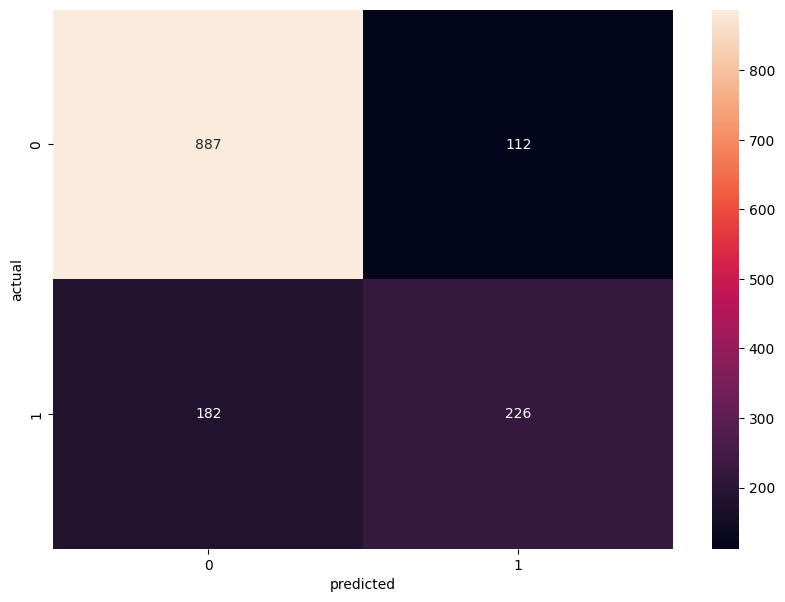

In [100]:
import seaborn as sns
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()